# EDA inicial · cancelación de reservas

Este notebook es **la cocina**: aquí se explora, se prueba y se falla. Lo que salga en
limpio se mueve a `src/data_loader.py`, y la versión presentable va a
`notebooks/finales/eda_final.ipynb`.

La regla que no se rompe: **cada hallazgo tiene que terminar en una decisión.** El EDA no
puntúa por número de gráficos, puntúa por lo que cambió. Ve apuntando la tabla del final.

> Lánzalo desde la raíz del proyecto, para que `from src import config` funcione.

In [1]:
import sys, pathlib

# subir hasta la raíz del proyecto (la carpeta que contiene src/), la abras desde donde la abras
raiz = next(d for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (d / "src").is_dir())
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("CSV:", config.DATA_RAW.name, "· %.1f MB" % (config.DATA_RAW.stat().st_size / 1e6))

CSV: dataset_practica_final.csv · 16.9 MB


## 1. La primera trampa: los nulos que no parecen nulos

`company` y `agent` traen el texto **`"NULL"`**, que pandas lee como una cadena normal.
Si tu primer `isna()` sale limpio no es que no haya huecos: es que no los has encontrado.

In [2]:
crudo   = pd.read_csv(config.DATA_RAW)
correcto = pd.read_csv(config.DATA_RAW, na_values=["NULL", "null", "", " "])

comparativa = pd.DataFrame({
    "sin na_values": crudo.isna().sum(),
    "con na_values": correcto.isna().sum(),
})
comparativa["diferencia"] = comparativa["con na_values"] - comparativa["sin na_values"]
display(comparativa[comparativa["con na_values"] > 0])

df = correcto          # a partir de aquí, el bueno

,sin na_values,con na_values,diferencia
children,4,4,0
country,488,488,0
agent,16340,16340,0
company,112593,112593,0


**Decisión a tomar:** ¿`company` vacío significa «dato perdido» o «no aplica, es un
particular»? No es lo mismo, y cambia cómo se imputa. Míralo antes de seguir.

## 2. Forma, tipos y memoria

In [3]:
print("filas y columnas:", df.shape)
print("memoria: %.1f MB" % (df.memory_usage(deep=True).sum() / 1e6))
print()

tipos = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (100 * df.isna().mean()).round(2),
    "distintos": df.nunique(),
})
display(tipos.sort_values("% nulos", ascending=False))

filas y columnas: (119390, 32)


memoria: 98.5 MB



,tipo,nulos,% nulos,distintos
company,float64,112593,94.31,352
agent,float64,16340,13.69,333
country,object,488,0.41,177
hotel,object,0,0.00,2
previous_cancellations,int64,0,0.00,15
reservation_status,object,0,0.00,3
total_of_special_requests,int64,0,0.00,6
required_car_parking_spaces,int64,0,0.00,5
adr,float64,0,0.00,8879
customer_type,object,0,0.00,4


## 3. El objetivo: cuánto desbalanceo hay

De aquí sale el número que hunde a `accuracy` como métrica principal.

In [4]:
vc = df[config.OBJETIVO].value_counts().sort_index()
pct = 100 * vc / len(df)

print("no cancela (0): %6d  (%.2f %%)" % (vc[0], pct[0]))
print("sí cancela (1): %6d  (%.2f %%)" % (vc[1], pct[1]))
print("razón          : %.2f : 1" % (vc[0] / vc[1]))
print()
print("Un modelo que dijera SIEMPRE «no cancela» ya acertaría el %.2f %%." % pct[0])

no cancela (0):  75166  (62.96 %)
sí cancela (1):  44224  (37.04 %)
razón          : 1.70 : 1

Un modelo que dijera SIEMPRE «no cancela» ya acertaría el 62.96 %.


## 4. La fuga: la columna que es la respuesta con otro nombre

`reservation_status` no es una pista buena, **es la etiqueta escrita de otra forma**.
Si la dejas dentro, los cinco modelos sacan un AUC ≈ 1,000 y tu comparación no distingue
nada. La tabla de abajo lo demuestra: cada estado cae al 100 % en un solo valor del objetivo.

In [5]:
tab = pd.crosstab(df["reservation_status"], df[config.OBJETIVO])
display(tab)
print()
print("¿determina el objetivo al 100 %?",
      bool(((tab == 0).sum(axis=1) == 1).all()))
print()
print("columnas a eliminar por fuga:", config.FUGAS)
print("predictoras que quedan:", df.shape[1] - 1 - len(config.FUGAS))

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207



¿determina el objetivo al 100 %? True

columnas a eliminar por fuga: ['reservation_status', 'reservation_status_date']
predictoras que quedan: 29


## 5. Duplicados

In [6]:
dup = df.duplicated().sum()
print("filas duplicadas exactas: %d  (%.1f %%)" % (dup, 100 * dup / len(df)))
print()
print("Ojo: sin identificador de reserva, dos clientes con la misma reserva el mismo día")
print("son indistinguibles. Decide si son error o coincidencia — y justifícalo.")
print()
print("Si los quitas, hazlo ANTES del train_test_split: si una copia cae en train y otra")
print("en test, el modelo ya vio ese ejemplo exacto y su nota en test está inflada.")

filas duplicadas exactas: 31994  (26.8 %)

Ojo: sin identificador de reserva, dos clientes con la misma reserva el mismo día
son indistinguibles. Decide si son error o coincidencia — y justifícalo.

Si los quitas, hazlo ANTES del train_test_split: si una copia cae en train y otra
en test, el modelo ya vio ese ejemplo exacto y su nota en test está inflada.


## 6. Imposibles y atípicos

Un **imposible** es un valor que no puede existir y se corrige o se tira.
Un **atípico** es un valor raro pero real: se piensa antes de tocarlo.

In [7]:
sin_huespedes = df[(df.adults + df.children.fillna(0) + df.babies) == 0]
adr_negativo  = df[df.adr < 0]

print("reservas con 0 huéspedes : %d" % len(sin_huespedes))
print("adr negativo             : %d  (mínimo %.2f)" % (len(adr_negativo), df.adr.min()))
print("adr máximo               : %.2f   <- ¿imposible o cliente real?" % df.adr.max())
print()
display(df[["lead_time", "adr", "stays_in_week_nights", "babies"]].describe().T)

reservas con 0 huéspedes : 180
adr negativo             : 1  (mínimo -6.38)
adr máximo               : 5400.00   <- ¿imposible o cliente real?



,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## 7. Cardinalidad: qué pasa si haces one-hot de todo

Aquí se decide si `country`, `agent` y `company` entran tal cual o agrupadas.

**Cuidado con una trampa:** `agent` y `company` son identificadores, o sea categóricas,
pero pandas las lee como `float64` porque son números. `select_dtypes("object")` **no las
ve**, y son justo las dos de mayor cardinalidad. Si te fías de esa lista, te dejas fuera
685 de las 862 columnas que va a generar el one-hot.

In [8]:
X = df.drop(columns=[config.OBJETIVO, *config.FUGAS])

# categóricas de verdad = las de texto + los identificadores numéricos
DISFRAZADAS = ["agent", "company"]
GRANDES = ["country", "agent", "company"]

cats = [c for c in X.columns if X[c].dtype == "object"] + DISFRAZADAS
nums = [c for c in X.columns if c not in cats]
peque = [c for c in cats if c not in GRANDES]

card = X[cats].nunique().sort_values(ascending=False)
display(card.to_frame("categorías"))

base   = len(nums) + X[peque].nunique().sum()
altas  = X[GRANDES].nunique().sum()
print("numéricas                          : %3d" % len(nums))
print("one-hot de las %d categóricas pequeñas: %3d" % (len(peque), X[peque].nunique().sum()))
print("                             base   = %3d" % base)
print()
print("country + agent + company          : %3d   <- el %d %% del total"
      % (altas, round(100 * altas / (base + altas))))
print("TOTAL con one-hot de todo          : %3d   (%.1f x la base)"
      % (base + altas, (base + altas) / base))
print()
print("Agrupando las tres grandes en top-10 + «otros»: %d columnas" % (base + 3 * 11))

,categorías
company,352
agent,333
country,177
arrival_date_month,12
assigned_room_type,12
reserved_room_type,10
market_segment,8
meal,5
distribution_channel,5
customer_type,4


numéricas                          :  17
one-hot de las 9 categóricas pequeñas:  61
                             base   =  78

country + agent + company          : 862   <- el 92 % del total
TOTAL con one-hot de todo          : 940   (12.1 x la base)

Agrupando las tres grandes en top-10 + «otros»: 111 columnas


## 8. Correlación con el objetivo

Solo funciona con numéricas. Sirve para dos cosas: ver dónde hay señal y **detectar fugas
numéricas** — la alarma no es un valor alto, es un valor que se despega del resto.

In [9]:
num = df.select_dtypes("number").drop(columns=[config.OBJETIVO])
corr = num.corrwith(df[config.OBJETIVO]).sort_values(key=abs, ascending=False)
display(corr.to_frame("r con is_canceled").round(3))

print("la más alta: %s con %.3f" % (corr.abs().idxmax(), corr[corr.abs().idxmax()]))
print("si alguna pasara de 0,80, sospecha fuga.")

,r con is_canceled
lead_time,0.293
total_of_special_requests,-0.235
required_car_parking_spaces,-0.195
booking_changes,-0.144
previous_cancellations,0.110
is_repeated_guest,-0.085
agent,-0.083
adults,0.060
previous_bookings_not_canceled,-0.057
days_in_waiting_list,0.054


la más alta: lead_time con 0.293
si alguna pasara de 0,80, sospecha fuga.


## 9. Dónde está la señal de verdad: tasa de cancelación por grupo

Esto rinde mucho más que la correlación, porque funciona con las categóricas — que es
donde está lo gordo de este dataset.

In [10]:
def tasa(col, minimo=200):
    g = df.groupby(col)[config.OBJETIVO].agg(["mean", "count"])
    g = g[g["count"] >= minimo].sort_values("mean", ascending=False)
    g.columns = ["tasa de cancelación", "reservas"]
    g["tasa de cancelación"] = (100 * g["tasa de cancelación"]).round(1)
    return g

for c in ["deposit_type", "market_segment", "customer_type", "hotel"]:
    print("──", c)
    display(tasa(c))

── deposit_type


,tasa de cancelación,reservas
deposit_type,,
Non Refund,99.4,14587
No Deposit,28.4,104641


── market_segment


,tasa de cancelación,reservas
market_segment,,
Groups,61.1,19811
Online TA,36.7,56477
Offline TA/TO,34.3,24219
Aviation,21.9,237
Corporate,18.7,5295
Direct,15.3,12606
Complementary,13.1,743


── customer_type


,tasa de cancelación,reservas
customer_type,,
Transient,40.7,89613
Contract,31.0,4076
Transient-Party,25.4,25124
Group,10.2,577


── hotel


,tasa de cancelación,reservas
hotel,,
City Hotel,41.7,79330
Resort Hotel,27.8,40060


In [11]:
# Las numéricas también cuentan una historia si las miras como grupo
pide_parking = df.required_car_parking_spaces > 0
print("pide plaza de parking : %5d reservas · cancelan %.1f %%"
      % (pide_parking.sum(), 100 * df[pide_parking][config.OBJETIVO].mean()))
print("no pide               : %5d reservas · cancelan %.1f %%"
      % ((~pide_parking).sum(), 100 * df[~pide_parking][config.OBJETIVO].mean()))
print()
print("¿Es una variable útil o es otra fuga encubierta? Piénsalo: ¿cuándo se rellena ese")
print("dato, en el momento de reservar o después? Esa pregunta es la que hay que hacerse")
print("con TODA columna sospechosamente buena.")

pide plaza de parking :  7416 reservas · cancelan 0.0 %
no pide               : 111974 reservas · cancelan 39.5 %

¿Es una variable útil o es otra fuga encubierta? Piénsalo: ¿cuándo se rellena ese
dato, en el momento de reservar o después? Esa pregunta es la que hay que hacerse
con TODA columna sospechosamente buena.


## 10. Distribuciones que conviene mirar

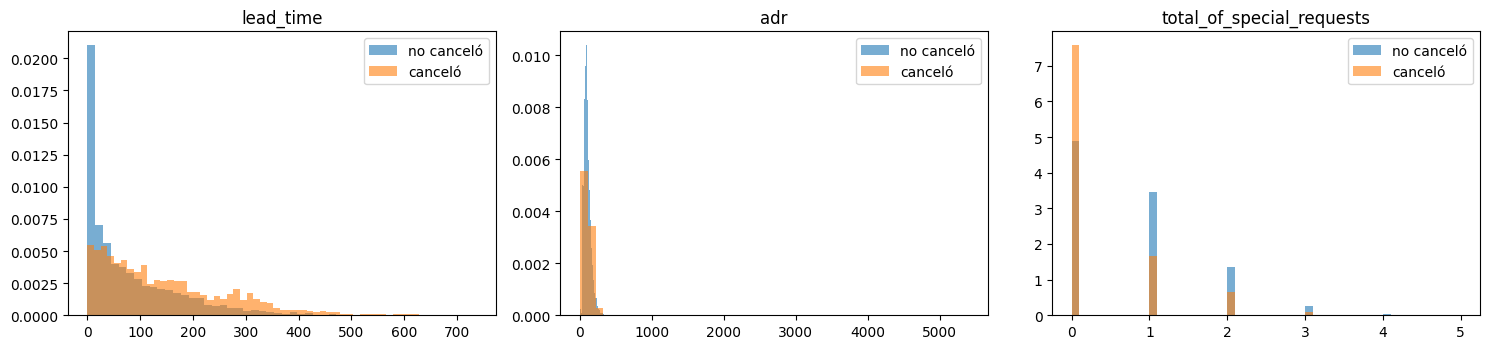

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))

for a, col in zip(ax, ["lead_time", "adr", "total_of_special_requests"]):
    for v, etq in [(0, "no canceló"), (1, "canceló")]:
        a.hist(df.loc[df[config.OBJETIVO] == v, col].dropna(),
               bins=50, alpha=.6, label=etq, density=True)
    a.set_title(col)
    a.legend()

plt.tight_layout()
plt.show()

---

## La tabla que va al README

Rellénala según vayas cerrando decisiones. **Es el apartado 3 del informe**, y es lo que
puntúa: no los gráficos, sino lo que cambiaste por haberlos mirado.

| Hallazgo | Evidencia | Decisión |
|---|---|---|
| `company` y `agent` traen `"NULL"` como texto | celda 1 | leer con `na_values=["NULL"]` |
| `reservation_status` determina el objetivo al 100 % | celda 4 | eliminar, junto con `reservation_status_date` |
| | | |

## Siguiente paso

Cuando una decisión esté cerrada, **múevela a `src/data_loader.py`** y borra el
experimento de aquí. Este notebook no tiene que quedar bonito; `eda_final.ipynb` sí.